In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

tune = "../artifacts/eval/eval_results_checkpoint_epochbest_20260924-055637.pt"
tune_reverse = "../artifacts/eval/eval_results_checkpoint_epochbest_20260924-055622.pt"

upper_reverse = "../artifacts/eval/eval_results_checkpoint_epochbest_20260924-055618.pt"
upper = "../artifacts/eval/eval_results_checkpoint_epochbest_20260924-055620.pt"


baseline = "../artifacts/eval/eval_results_checkpoint_epochbest_20260924-055634.pt"

vae = "../artifacts/eval/eval_results_checkpoint_epochbest_20260924-055628.pt"
vae_baseline = "../artifacts/eval/eval_results_checkpoint_epochbest_20260924-055631.pt"

def get_json(path):
    with open(path, "r") as f:
        return json.load(f)

In [3]:
data_tune = get_json(tune)
data_tune_reverse = get_json(tune_reverse)
data_upper_reverse = get_json(upper_reverse)
data_upper = get_json(upper)

data_baseline = get_json(baseline)

data_vae = get_json(vae)
data_vae_baseline = get_json(vae_baseline)


In [4]:
def object_to_dataframe(data, rnn=False):
    to_return = {}
    to_return["x"] = data["x"]
    to_return["mean"] = data["mean"]
    to_return["logvar"] = data["logvar"]
    to_return["losses"] = data["losses"]    
    to_return["losses_position"] = data["losses_position"]
    to_return["mse_losses"] = data["mse_losses"]
    to_return["mse_losses_position"] = data["mse_losses_position"]

    to_return["mse_loss"] = data["mse_loss"]
    #to_return["losses"] = data["losses"]
    for key in ["losses_position", "mse_losses_position"]:
        for sublist in data[key]:
            sublist[13] = sublist[12]*0.5 + sublist[14]*0.5
    for k in list(to_return.keys()):
        try:
            print("Key: ", k , " Len: ", len(to_return[k]))
        except:
            print("did not work for" , k)


    


    return pd.DataFrame.from_dict(to_return)


In [5]:

df_baseline = object_to_dataframe(data_baseline, rnn=True)

df_tune = object_to_dataframe(data_tune)
df_tune_reverse = object_to_dataframe(data_tune_reverse)
df_upper_reverse = object_to_dataframe(data_upper_reverse)
df_upper = object_to_dataframe(data_upper)


df_vae = object_to_dataframe(data_vae)
df_vae_baseline = object_to_dataframe(data_vae_baseline)

Key:  x  Len:  944
Key:  mean  Len:  944
Key:  logvar  Len:  944
Key:  losses  Len:  944
Key:  losses_position  Len:  944
Key:  mse_losses  Len:  944
Key:  mse_losses_position  Len:  944
did not work for mse_loss
Key:  x  Len:  944
Key:  mean  Len:  944
Key:  logvar  Len:  944
Key:  losses  Len:  944
Key:  losses_position  Len:  944
Key:  mse_losses  Len:  944
Key:  mse_losses_position  Len:  944
did not work for mse_loss
Key:  x  Len:  944
Key:  mean  Len:  944
Key:  logvar  Len:  944
Key:  losses  Len:  944
Key:  losses_position  Len:  944
Key:  mse_losses  Len:  944
Key:  mse_losses_position  Len:  944
did not work for mse_loss
Key:  x  Len:  944
Key:  mean  Len:  944
Key:  logvar  Len:  944
Key:  losses  Len:  944
Key:  losses_position  Len:  944
Key:  mse_losses  Len:  944
Key:  mse_losses_position  Len:  944
did not work for mse_loss
Key:  x  Len:  944
Key:  mean  Len:  944
Key:  logvar  Len:  944
Key:  losses  Len:  944
Key:  losses_position  Len:  944
Key:  mse_losses  Len:  94

(<Figure size 640x480 with 1 Axes>, <Axes: title={'center': 'NLL'}>)

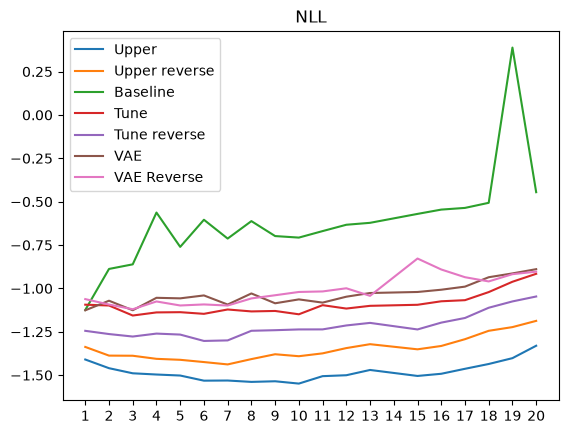

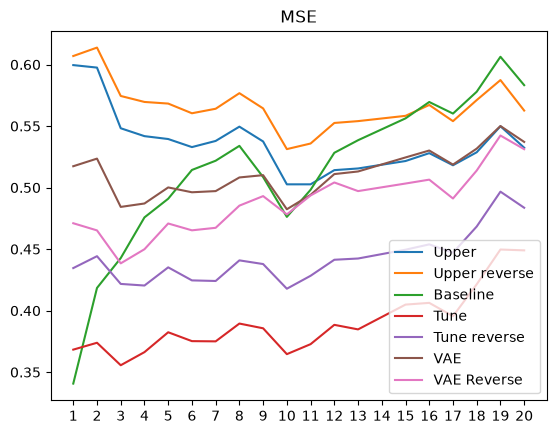

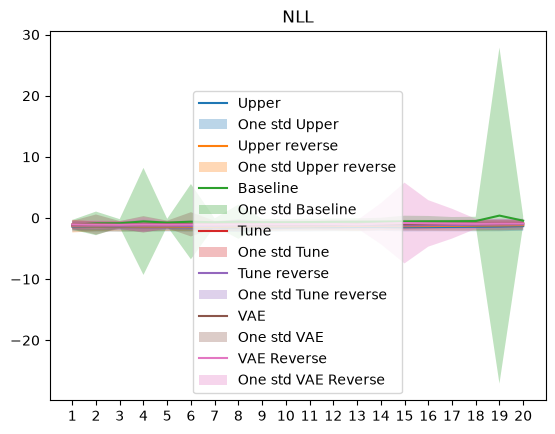

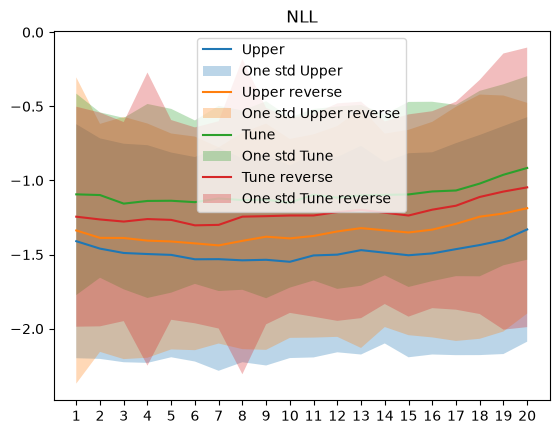

In [20]:


def get_horizon_error_std(models, title, labels):
    fig, ax = plt.subplots()

    for m, label in zip(models, labels):
        errors = np.stack(m)

        mean = np.mean(errors, axis=0)
        std = np.std(errors, axis=0)

        lower = mean - std
        upper = mean + std

        x = np.arange(1, len(mean) + 1)

        ax.plot(x, mean, label=label)
        ax.fill_between(
            x,
            lower,
            upper,
            alpha=0.3,
            label=f"One std {label}"
        )

    ax.set_xticks(x)
    ax.set_title(title)
    ax.legend()

    return fig, ax

    
def get_horizon_error(models, title, labels):
    fig, ax = plt.subplots()

    for m, label in zip(models, labels):
        errors = np.stack(m)

        mean = np.mean(errors, axis=0)
        #std = np.std(errors, axis=0)

        #lower = mean - std
        #upper = mean + std

        x = np.arange(1, len(mean) + 1)

        ax.plot(x, mean, label=label)
        """
        ax.fill_between(
            x,
            lower,
            upper,
            alpha=0.3,
            label=f"One std {label}"
        )
        """

    ax.set_xticks(x)
    ax.set_title(title)
    ax.legend()

    return fig, ax

get_horizon_error(models=[df_upper["losses_position"],
                   df_upper_reverse["losses_position"],
                   df_baseline["losses_position"],
                   df_tune["losses_position"],
                   data_tune_reverse["losses_position"],
                   data_vae["losses_position"],
                   data_vae_baseline["losses_position"],
                  ],
                   title="NLL",
                  labels=[
                      "Upper",
                      "Upper reverse",
                      "Baseline",
                      "Tune",
                      "Tune reverse",
                      "VAE",
                      "VAE Reverse",
                  ])


get_horizon_error(models=[df_upper["mse_losses_position"],
                   df_upper_reverse["mse_losses_position"],
                   df_baseline["mse_losses_position"],
                   df_tune["mse_losses_position"],
                   data_tune_reverse["mse_losses_position"],
                   data_vae["mse_losses_position"],
                   data_vae_baseline["mse_losses_position"],
                  ],
                   title="MSE",
                  labels=[
                      "Upper",
                      "Upper reverse",
                      "Baseline",
                      "Tune",
                      "Tune reverse",
                      "VAE",
                      "VAE Reverse",
                  ])
                   
get_horizon_error_std(models=[df_upper["losses_position"],
                   df_upper_reverse["losses_position"],
                   df_baseline["losses_position"],
                   df_tune["losses_position"],
                   data_tune_reverse["losses_position"],
                   data_vae["losses_position"],
                   data_vae_baseline["losses_position"],
                  ],
                   title="NLL",
                  labels=[
                      "Upper",
                      "Upper reverse",
                      "Baseline",
                      "Tune",
                      "Tune reverse",
                      "VAE",
                      "VAE Reverse",
                  ])    
                   



get_horizon_error_std(models=[
                    df_upper["losses_position"],
                   df_upper_reverse["losses_position"],
                   #df_baseline["losses_position"],
                   df_tune["losses_position"],
                   data_tune_reverse["losses_position"],
                   #data_vae["losses_position"],
                   #data_vae_baseline["losses_position"],
                  ],
                   title="NLL",
                  labels=[
                      "Upper",
                      "Upper reverse",
                      #"Baseline",
                      "Tune",
                      "Tune reverse",
                      #"VAE",
                      #"VAE Reverse",
                  ])   

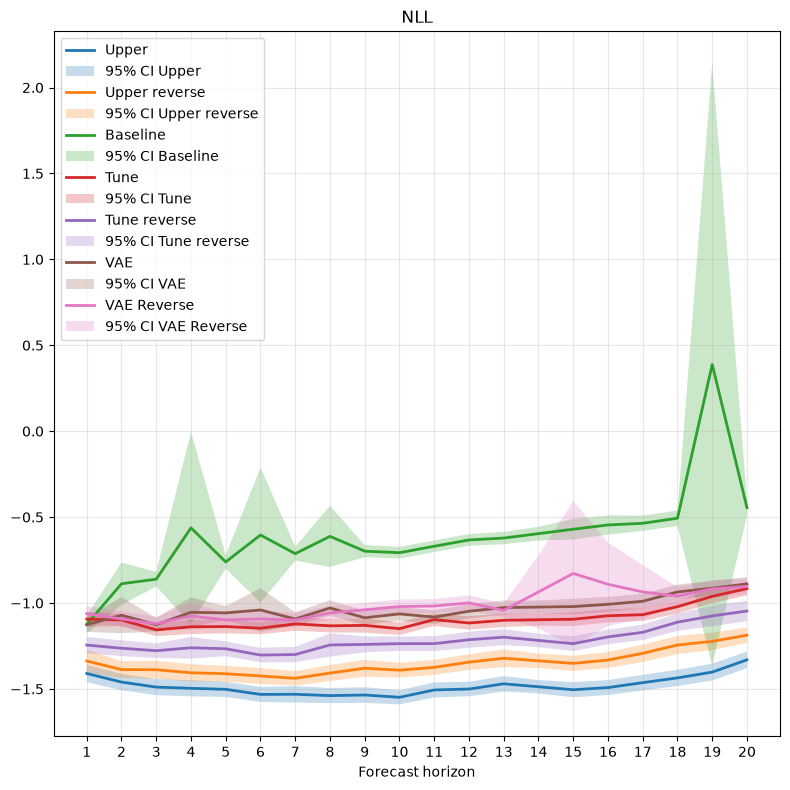

In [19]:
import numpy as np
import matplotlib.pyplot as plt


def plot_horizon_metric(models, labels, title="title"):
    fig, ax = plt.subplots(figsize=(8, 8))

    for m, label in zip(models, labels):
        errors = np.stack(m)

        mean = np.mean(errors, axis=0)
        std = np.std(errors, axis=0, ddof=1)

        n = errors.shape[0]

        # 95% confidence interval
        ci = 1.96 * std / np.sqrt(n)

        x = np.arange(1, len(mean) + 1)

        ax.plot(
            x,
            mean,
            lw=2,
            label=label
        )

        ax.fill_between(
            x,
            mean - ci,
            mean + ci,
            alpha=0.25,
            label=f"95% CI {label}"
        )

    ax.set_xlabel("Forecast horizon")
    ax.set_xticks(x)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_horizon_metric(models=[df_upper["losses_position"],
                   df_upper_reverse["losses_position"],
                   df_baseline["losses_position"],
                   df_tune["losses_position"],
                   data_tune_reverse["losses_position"],
                   data_vae["losses_position"],
                   data_vae_baseline["losses_position"],
                  ],
                   title="NLL",
                  labels=[
                      "Upper",
                      "Upper reverse",
                      "Baseline",
                      "Tune",
                      "Tune reverse",
                      "VAE",
                      "VAE Reverse",
                  ]) 


In [ ]:
def plot_difference(new, old, title):
    errors_new = np.stack(new)
    errors_old = np.stack(old)

    diff = errors_new - errors_old

    mean_diff = np.mean(diff, axis=0)
    std_diff = np.std(diff, axis=0, ddof=1)

    ci = 1.96 * std_diff / np.sqrt(diff.shape[0])

    x = np.arange(1, len(mean_diff) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.axhline(0, color="black", linestyle="--", alpha=0.7)

    ax.plot(x, mean_diff, lw=2, color="tab:green")

    ax.fill_between(
        x,
        mean_diff - ci,
        mean_diff + ci,
        alpha=0.25,
        color="tab:green"
    )

    ax.set_xlabel("Forecast horizon")
    ax.set_ylabel("New − Old")
    ax.set_title(title)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


print("MSE")
plot_difference(
    df_new["mse_losses_position"],
    df_old["mse_losses_position"],
    "MSE"
)

print("NLL")
plot_difference(
    df_new["losses_position"],
    df_old["losses_position"],
    "NLL"
)